# Solid-Solution Strengthened (SSS) Alloys — Evaluation

**38 alloys, 257 datapoints, −196 to 1204°C** — Hastelloy B/C/X, Inconel 600/625/N06230, Haynes 242/718, TD NiCr, etc.

Four ablation levels: **ML-only** → **ML + deterministic physics** → **Full system (+ KG + agents)** → **LLM-only** baseline.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.25,
                      'font.size': 10, 'figure.facecolor': 'white'})

R = Path('../results/SSS')
ml   = pd.read_csv(R / 'ml_only.csv')
det  = pd.read_csv(R / 'ml_deterministic.csv')
full = pd.read_csv(R / 'full_system.csv')
llm  = pd.read_csv(R / 'llm_only.csv')

METHODS = {'ML': ml, 'ML+Phys': det, 'Full': full, 'LLM': llm}
COLORS  = {'ML': '#4C72B0', 'ML+Phys': '#55A868', 'Full': '#C44E52', 'LLM': '#8172B2'}
PROPS   = [('pred_ys','actual_ys','YS (MPa)'), ('pred_uts','actual_uts','UTS (MPa)'),
           ('pred_el','actual_el','EL (%)'),    ('pred_em','actual_em','EM (GPa)')]

def metrics(df, pc, ac):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)<2: return dict(n=len(v), mape=np.nan, rmse=np.nan, r2=np.nan, bias=np.nan)
    e = v[pc]-v[ac]; pe = e/v[ac]
    return dict(n=len(v), mape=pe.abs().mean()*100, rmse=np.sqrt((e**2).mean()),
                r2=r2_score(v[ac], v[pc]), bias=pe.mean()*100)

def pct_within(df, pc, ac, tol):
    v = df[[pc,ac]].dropna(); v = v[v[ac]!=0]
    if len(v)==0: return np.nan
    return (((v[pc]-v[ac])/v[ac]).abs()*100 <= tol).mean()*100

## Table 1 — Aggregate Accuracy

In [2]:
rows = []
for mn, df in METHODS.items():
    for pc, ac, lbl in PROPS:
        m = metrics(df, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '±10%': pct_within(df,pc,ac,10), '±20%': pct_within(df,pc,ac,20)})

tbl = pd.DataFrame(rows)
for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = tbl[tbl['Property']==prop][['Method','n','mape','rmse','r2','bias','±10%','±20%']].set_index('Method')
    sub.columns = ['n','MAPE %','RMSE','R²','Bias %','±10%','±20%']
    print(f"\n{prop}")
    display(sub.style.format({'MAPE %':'{:.1f}','RMSE':'{:.1f}','R²':'{:.3f}',
                              'Bias %':'{:+.1f}','±10%':'{:.0f}%','±20%':'{:.0f}%','n':'{:.0f}'})
            .highlight_min(subset=['MAPE %','RMSE'], props='font-weight:bold;color:green')
            .highlight_max(subset=['R²','±10%','±20%'], props='font-weight:bold;color:green'))


YS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,147,52.2,131.7,0.693,+46.3,20%,37%
ML+Phys,147,52.2,131.7,0.693,+46.3,20%,37%
Full,133,32.8,108.6,0.681,+20.6,29%,45%
LLM,147,124.6,424.6,-2.185,+119.7,7%,15%



UTS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,151,30.3,147.6,0.758,+25.8,26%,48%
ML+Phys,151,30.6,146.9,0.760,+24.9,25%,50%
Full,135,21.0,135.4,0.754,+6.7,27%,57%
LLM,151,73.2,374.5,-0.558,+70.3,11%,18%



EL (%)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,150,90.2,18.4,0.186,+62.4,23%,42%
ML+Phys,150,90.2,18.4,0.186,+62.4,23%,42%
Full,135,116.7,23.7,-0.308,+86.2,20%,43%
LLM,150,81.5,30.9,-1.284,-5.9,7%,11%



EM (GPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,176,7.2,20.9,0.175,-4.8,77%,87%
ML+Phys,176,4.8,12.4,0.709,-2.2,88%,98%
Full,159,4.4,9.9,0.814,-2.1,93%,100%
LLM,176,54766.4,149621.2,-42195566.744,+54765.4,29%,42%


## Table 2 — Accuracy by Temperature Regime

MAPE (%) for YS and UTS split into three regimes: RT (< 100°C), mid-temperature (100–700°C), and high-temperature (> 700°C).

In [3]:
def temp_regime(t):
    if t < 100: return 'RT (< 100\u00b0C)'
    elif t <= 700: return 'Mid (100\u2013700\u00b0C)'
    else: return 'High (> 700\u00b0C)'

REGIMES = ['RT (< 100\u00b0C)', 'Mid (100\u2013700\u00b0C)', 'High (> 700\u00b0C)']

rows = []
for mn, df in METHODS.items():
    df = df.copy()
    df['regime'] = df['temperature'].apply(temp_regime)
    for regime in REGIMES:
        sub = df[df['regime'] == regime]
        for pc, ac, lbl in [('pred_ys','actual_ys','YS'), ('pred_uts','actual_uts','UTS')]:
            m = metrics(sub, pc, ac)
            rows.append({'Regime': regime, 'Property': lbl, 'Method': mn,
                         'n': m['n'], 'MAPE': m['mape']})

temp_tbl = pd.DataFrame(rows)
pivot = temp_tbl.pivot_table(index=['Regime', 'Property'], columns='Method', values='MAPE')
pivot = pivot[['ML', 'ML+Phys', 'Full', 'LLM']]

n_ref = temp_tbl[temp_tbl['Method']=='ML'][['Regime','Property','n']].set_index(['Regime','Property'])
pivot = n_ref.join(pivot)
pivot.index = pivot.index.set_levels([REGIMES, ['YS', 'UTS']])

display(pivot.style.format({'n': '{:.0f}', 'ML': '{:.1f}', 'ML+Phys': '{:.1f}',
                            'Full': '{:.1f}', 'LLM': '{:.1f}'}, na_rep='\u2014')
        .highlight_min(subset=['ML', 'ML+Phys', 'Full', 'LLM'], axis=1,
                       props='font-weight:bold;color:green'))

## Fig. 1 — Cumulative Accuracy Curves

What tolerance band is needed to capture 80% of predictions?

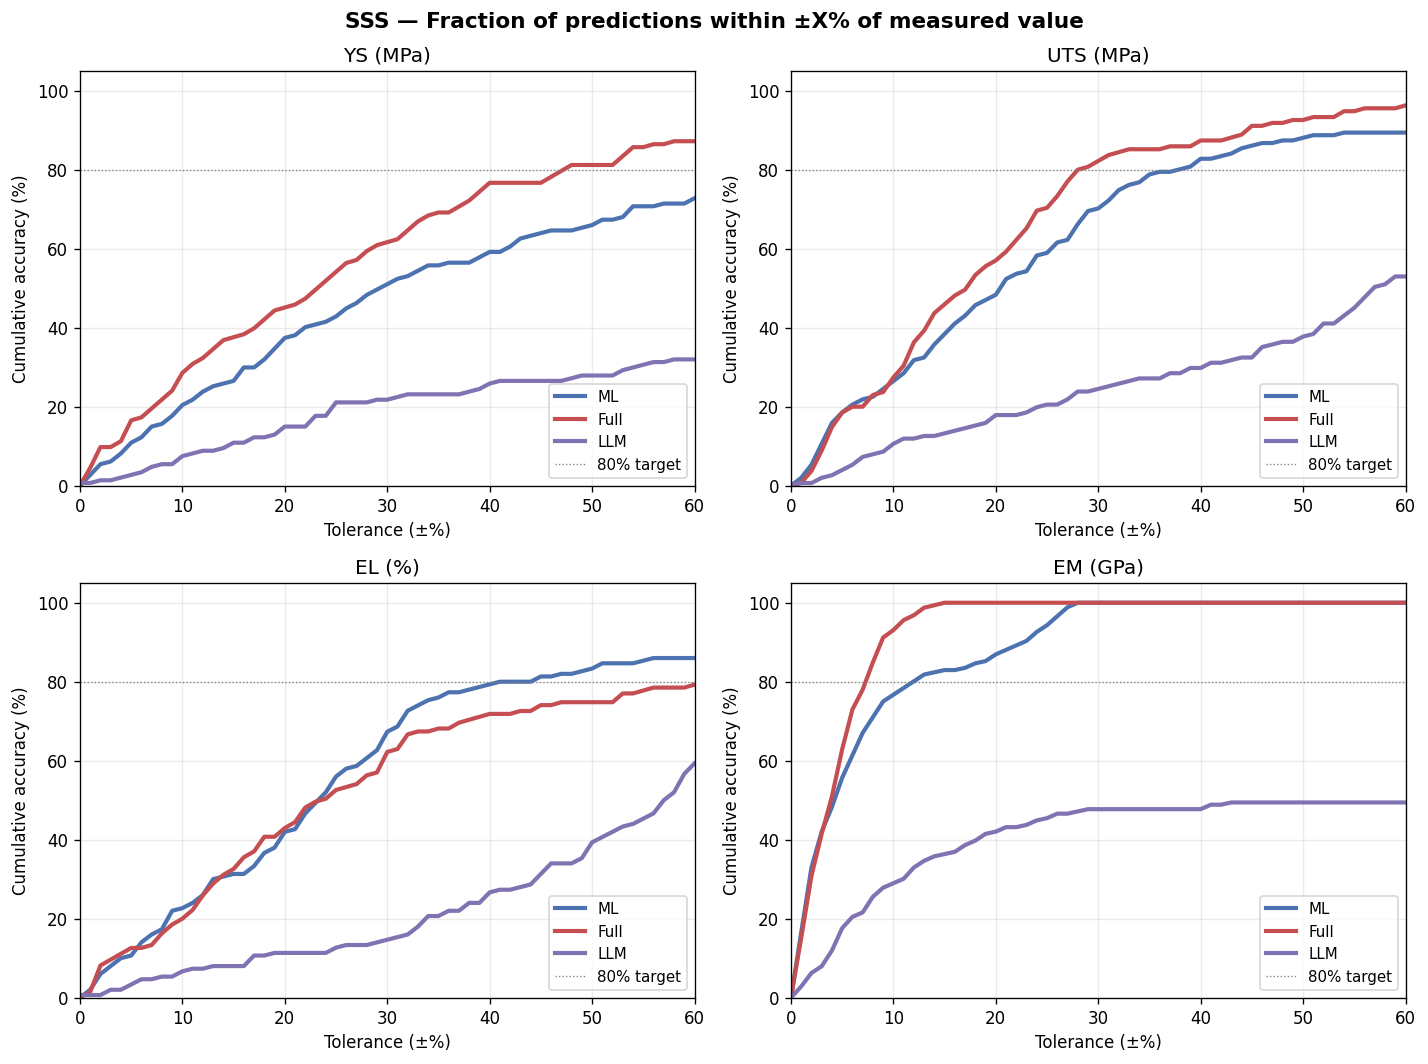

In [4]:
PLOT_METHODS = {'ML': ml, 'Full': full, 'LLM': llm}
PLOT_COLORS  = {'ML': '#4C72B0', 'Full': '#C44E52', 'LLM': '#8172B2'}

tol = np.arange(0, 61, 1)
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    for mn, df in PLOT_METHODS.items():
        acc = [pct_within(df, pc, ac, t) for t in tol]
        ax.plot(tol, acc, label=mn, color=PLOT_COLORS[mn], lw=2.5)
    ax.axhline(80, color='gray', ls=':', lw=0.8, label='80% target')
    ax.set(xlabel='Tolerance (\u00b1%)', ylabel='Cumulative accuracy (%)',
           title=lbl, xlim=(0, 60), ylim=(0, 105))
    ax.legend(fontsize=9, loc='lower right')

fig.suptitle('SSS \u2014 Fraction of predictions within \u00b1X% of measured value',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 2 — Predicted vs Measured (Full System)

Parity plots for all four properties. Green band = ±10% tolerance; points within band shown in blue, outliers as red crosses.

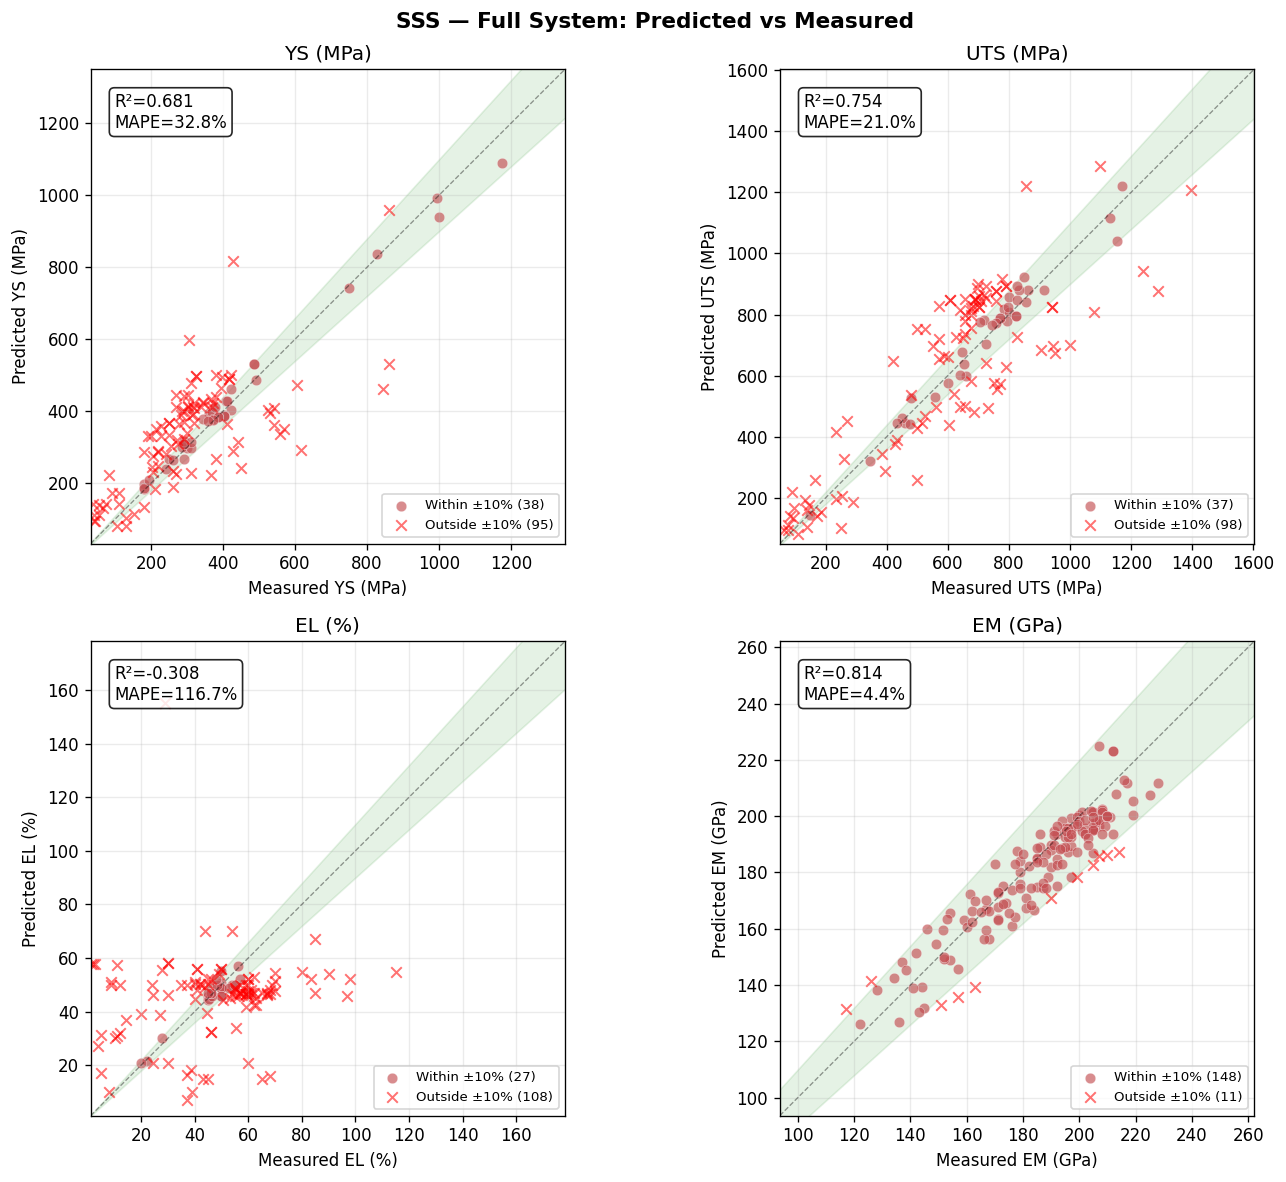

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (pc, ac, lbl) in zip(axes.ravel(), PROPS):
    v = full[[pc, ac]].dropna()
    v = v[v[ac] != 0].copy()
    m = metrics(full, pc, ac)
    pe = ((v[pc] - v[ac]) / v[ac]).abs() * 100
    w = pe <= 10

    lo = min(v[ac].min(), v[pc].min()) * 0.8
    hi = max(v[ac].max(), v[pc].max()) * 1.15
    d = np.linspace(lo, hi, 100)
    ax.fill_between(d, d * 0.9, d * 1.1, alpha=0.10, color='green')
    ax.plot(d, d, 'k--', lw=0.8, alpha=0.4)

    ax.scatter(v.loc[w, ac], v.loc[w, pc], s=40, alpha=0.65,
               color=COLORS['Full'], edgecolors='white', lw=0.3,
               label=f'Within ±10% ({w.sum()})')
    ax.scatter(v.loc[~w, ac], v.loc[~w, pc], s=40, alpha=0.55,
               color='red', marker='x', lw=1.2,
               label=f'Outside ±10% ({(~w).sum()})')

    ax.text(0.05, 0.95, f"R²={m['r2']:.3f}\nMAPE={m['mape']:.1f}%",
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85))
    ax.set(xlabel=f'Measured {lbl}', ylabel=f'Predicted {lbl}',
           title=lbl, xlim=(lo, hi), ylim=(lo, hi), aspect='equal')
    ax.legend(fontsize=8, loc='lower right')

fig.suptitle('SSS — Full System: Predicted vs Measured', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Fig. 3 — Case Studies: Temperature Sweeps

Two well-characterized SSS alloys with full RT-to-1100°C coverage, showing YS and UTS predictions against published datasheet values.

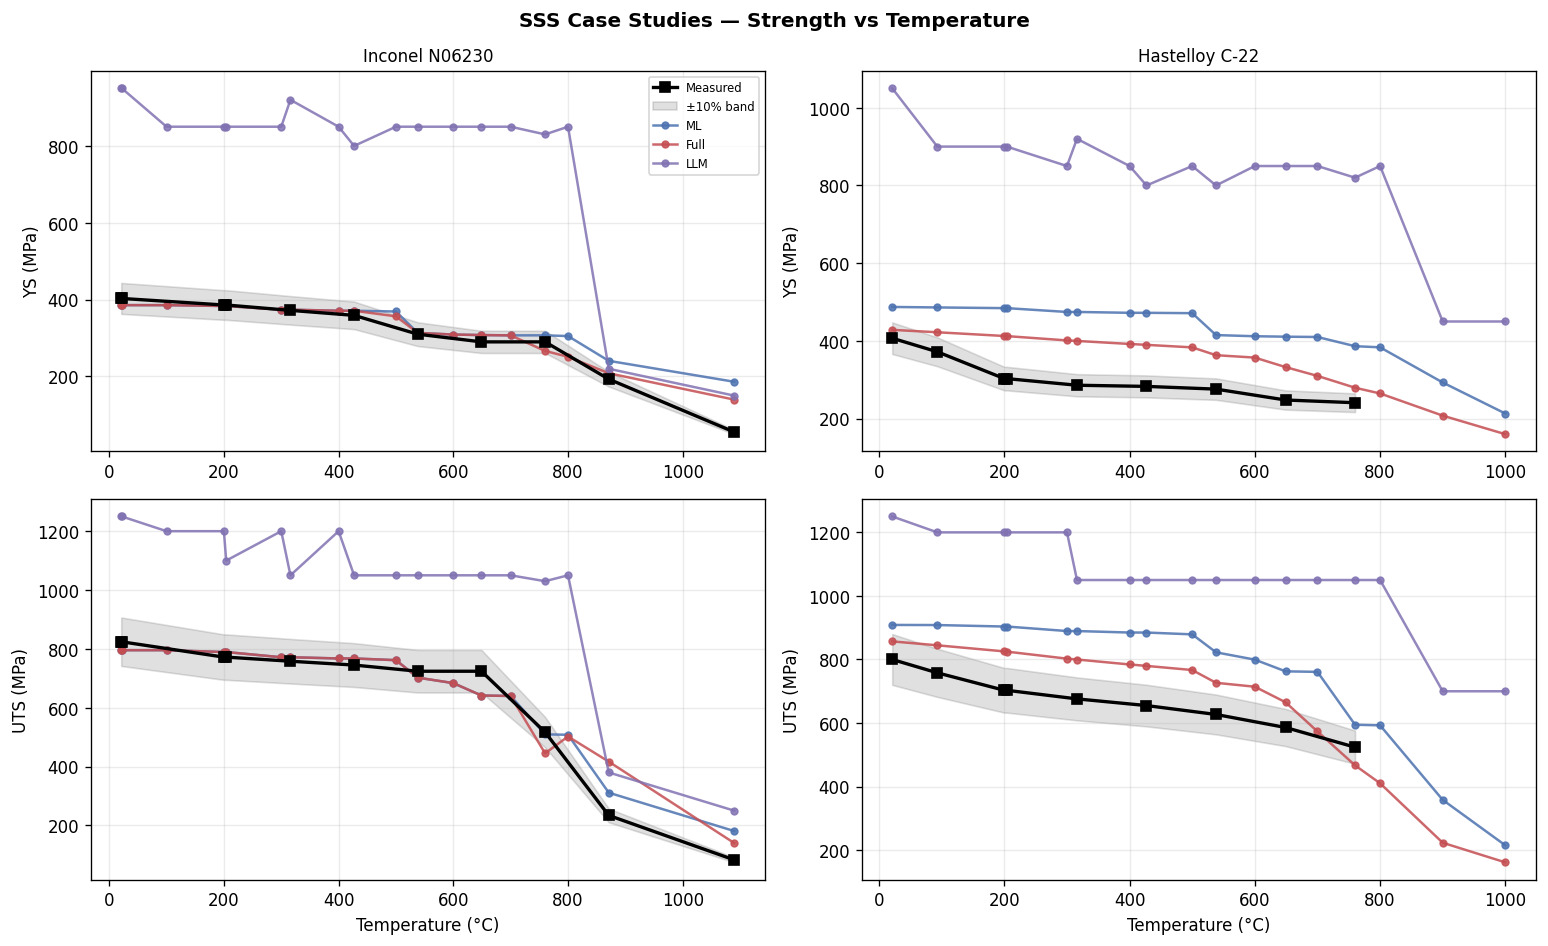

In [6]:
cases = [
    'Special Metals INCONEL\u00ae Alloy N06230 Ni-Cr-W-Mo Alloy',
    'Haynes Hastelloy\u00ae C-22\u00ae alloy',
]
short_names = ['Inconel N06230', 'Hastelloy C-22']

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('SSS Case Studies \u2014 Strength vs Temperature', fontsize=12, fontweight='bold')

for col, (alloy, sname) in enumerate(zip(cases, short_names)):
    for row, (pc, ac, ylabel) in enumerate([('pred_ys','actual_ys','YS (MPa)'),
                                             ('pred_uts','actual_uts','UTS (MPa)')]):
        ax = axes[row, col]
        ref = ml[ml['alloy']==alloy].sort_values('temperature')
        actual = ref[['temperature',ac]].dropna()
        if not actual.empty:
            ax.plot(actual['temperature'], actual[ac], 'ks-', ms=6, lw=2,
                    label='Measured', zorder=5)
            ax.fill_between(actual['temperature'], actual[ac]*0.9, actual[ac]*1.1,
                            alpha=0.12, color='black', label='\u00b110% band')

        for mn in ['ML', 'Full', 'LLM']:
            sub = METHODS[mn][METHODS[mn]['alloy']==alloy].sort_values('temperature')
            v = sub[['temperature',pc]].dropna()
            if not v.empty:
                ax.plot(v['temperature'], v[pc], 'o-', ms=4, lw=1.5,
                        color=COLORS[mn], label=mn, alpha=0.85)

        if row == 0: ax.set_title(sname, fontsize=10)
        ax.set(xlabel='Temperature (\u00b0C)' if row==1 else '', ylabel=ylabel)
        if col==0 and row==0: ax.legend(fontsize=7, loc='upper right')

plt.tight_layout()
plt.show()

## Appendix — Comparison with GPT-4.1-mini

GPT-4.1-mini was evaluated on a **subset** of the test set due to data availability constraints. To ensure a fair comparison, all methods below are restricted to the common evaluation set (alloy-temperature pairs present in the GPT files). Coverage and prediction-success rates are reported alongside accuracy metrics.

In [7]:
# --- Load GPT-4.1-mini results and build common evaluation set ---
gpt41m    = pd.read_csv(R / 'gpt4.1.csv')
gpt41m_ft = pd.read_csv(R / 'gpt4.1_ft.csv')

common_pairs = gpt41m[['alloy', 'temperature']].drop_duplicates()

ALL_METHODS = {**METHODS, 'GPT-4.1-mini': gpt41m, 'GPT-4.1-mini-FT': gpt41m_ft}
ALL_COLORS  = {**COLORS, 'GPT-4.1-mini': '#FF7F0E', 'GPT-4.1-mini-FT': '#D62728'}
COMMON = {}
for mn, df in ALL_METHODS.items():
    COMMON[mn] = common_pairs.merge(df, on=['alloy', 'temperature'], how='inner')

print(f"Full test set: {len(ml)} datapoints")
print(f"Common evaluation set: {len(common_pairs)} datapoints")
print(f"\nPrediction coverage (successful predictions / common set):")
for mn, df in COMMON.items():
    for pc, ac, lbl in PROPS[:2]:
        n_valid = df[[pc, ac]].dropna().pipe(lambda v: v[v[ac] != 0]).shape[0]
        print(f"  {mn:20s}  {lbl}: {n_valid:3d}/{len(common_pairs)} ({n_valid/len(common_pairs)*100:.0f}%)")

# --- Accuracy on common subset ---
print("\n" + "="*60)
rows = []
for mn, df in COMMON.items():
    for pc, ac, lbl in PROPS:
        m = metrics(df, pc, ac)
        rows.append({**m, 'Method': mn, 'Property': lbl,
                     '\u00b110%': pct_within(df, pc, ac, 10),
                     '\u00b120%': pct_within(df, pc, ac, 20)})

gpt_tbl = pd.DataFrame(rows)
for prop in ['YS (MPa)', 'UTS (MPa)', 'EL (%)', 'EM (GPa)']:
    sub = gpt_tbl[gpt_tbl['Property']==prop][['Method','n','mape','rmse','r2','bias','\u00b110%','\u00b120%']].set_index('Method')
    sub.columns = ['n','MAPE %','RMSE','R\u00b2','Bias %','\u00b110%','\u00b120%']
    print(f"\n{prop}")
    display(sub.style.format({'MAPE %':'{:.1f}','RMSE':'{:.1f}','R\u00b2':'{:.3f}',
                              'Bias %':'{:+.1f}','\u00b110%':'{:.0f}%','\u00b120%':'{:.0f}%','n':'{:.0f}'})
            .highlight_min(subset=['MAPE %','RMSE'], props='font-weight:bold;color:green')
            .highlight_max(subset=['R\u00b2','\u00b110%','\u00b120%'], props='font-weight:bold;color:green'))

Full test set: 257 datapoints
Common evaluation set: 143 datapoints

Prediction coverage (successful predictions / common set):
  ML                    YS (MPa): 138/143 (97%)
  ML                    UTS (MPa): 142/143 (99%)
  ML+Phys               YS (MPa): 138/143 (97%)
  ML+Phys               UTS (MPa): 142/143 (99%)
  Full                  YS (MPa): 125/143 (87%)
  Full                  UTS (MPa): 127/143 (89%)
  LLM                   YS (MPa): 138/143 (97%)
  LLM                   UTS (MPa): 142/143 (99%)
  GPT-4.1-mini          YS (MPa):  57/143 (40%)
  GPT-4.1-mini          UTS (MPa):  57/143 (40%)
  GPT-4.1-mini-FT       YS (MPa):  61/143 (43%)
  GPT-4.1-mini-FT       UTS (MPa):  61/143 (43%)


YS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,138,53.3,132.0,0.709,+47.0,20%,37%
ML+Phys,138,53.3,132.0,0.709,+47.0,20%,37%
Full,125,33.3,109.5,0.691,+20.4,28%,45%
LLM,138,121.5,414.3,-1.867,+116.2,8%,16%
GPT-4.1-mini,57,67.3,217.1,-1.071,+64.2,7%,18%
GPT-4.1-mini-FT,61,46.4,197.3,0.260,+34.9,23%,48%



UTS (MPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,142,31.0,147.6,0.769,+26.3,26%,47%
ML+Phys,142,31.4,147.1,0.770,+25.4,24%,49%
Full,127,21.4,136.3,0.760,+6.5,28%,55%
LLM,142,73.5,366.9,-0.429,+70.4,11%,19%
GPT-4.1-mini,57,69.9,296.1,-0.397,+66.8,16%,28%
GPT-4.1-mini-FT,61,34.2,218.3,0.445,+27.8,30%,64%



EL (%)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,141,94.7,18.8,0.193,+66.5,22%,41%
ML+Phys,141,94.7,18.8,0.193,+66.5,22%,41%
Full,127,122.5,24.2,-0.300,+91.4,20%,42%
LLM,141,83.7,31.1,-1.211,-3.2,7%,11%
GPT-4.1-mini,57,75.3,25.8,-0.084,+16.8,11%,30%
GPT-4.1-mini-FT,61,68.1,23.0,0.140,-5.7,10%,21%



EM (GPa)


,n,MAPE %,RMSE,R²,Bias %,±10%,±20%
Method,,,,,,,
ML,62,7.2,21.0,0.077,-5.5,81%,87%
ML+Phys,62,5.1,12.4,0.676,-3.0,90%,97%
Full,55,4.7,10.6,0.783,-2.7,95%,100%
LLM,62,58878.4,156326.2,-51273154.872,+58877.0,35%,42%
GPT-4.1-mini,28,7.0,15.6,0.557,+1.9,82%,86%
GPT-4.1-mini-FT,33,5.3,11.6,0.727,+2.5,82%,100%


In [8]:
# --- Precision / Recall / F1 (tolerance-based) ---
TOLERANCES = [10, 20]
total = len(common_pairs)

prf_rows = []
for tol_pct in TOLERANCES:
    for mn, df in COMMON.items():
        for pc, ac, lbl in PROPS:
            has_pred = df[[pc, ac]].dropna()
            has_pred = has_pred[has_pred[ac] != 0]
            n_predicted = len(has_pred)
            if n_predicted == 0:
                prf_rows.append({'Tol': f'\u00b1{tol_pct}%', 'Method': mn, 'Property': lbl,
                                 'Predicted': 0, 'Precision': np.nan, 'Recall': np.nan, 'F1': np.nan})
                continue
            within = (((has_pred[pc] - has_pred[ac]) / has_pred[ac]).abs() * 100 <= tol_pct)
            tp = within.sum()
            prec = tp / n_predicted * 100
            rec  = tp / total * 100
            f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
            prf_rows.append({'Tol': f'\u00b1{tol_pct}%', 'Method': mn, 'Property': lbl,
                             'Predicted': n_predicted, 'Precision': prec, 'Recall': rec, 'F1': f1})

prf_df = pd.DataFrame(prf_rows)
for tol_label in [f'\u00b1{t}%' for t in TOLERANCES]:
    sub = prf_df[prf_df['Tol'] == tol_label].pivot_table(
        index='Method', columns='Property', values=['Precision', 'Recall', 'F1'], sort=False)
    sub.columns = [f'{prop} {metric}' for metric, prop in sub.columns]
    print(f"\n{tol_label} Tolerance (common set: {total} pairs)")
    display(sub.style.format('{:.1f}%', na_rep='\u2014').highlight_max(props='font-weight:bold;color:green'))


±10% Tolerance (common set: 143 pairs)


,YS (MPa) Precision,UTS (MPa) Precision,EL (%) Precision,EM (GPa) Precision,YS (MPa) Recall,UTS (MPa) Recall,EL (%) Recall,EM (GPa) Recall,YS (MPa) F1,UTS (MPa) F1,EL (%) F1,EM (GPa) F1
Method,,,,,,,,,,,,
ML,20.3%,26.1%,22.0%,80.6%,19.6%,25.9%,21.7%,35.0%,19.9%,26.0%,21.8%,48.8%
ML+Phys,20.3%,23.9%,22.0%,90.3%,19.6%,23.8%,21.7%,39.2%,19.9%,23.9%,21.8%,54.6%
Full,28.0%,27.6%,19.7%,94.5%,24.5%,24.5%,17.5%,36.4%,26.1%,25.9%,18.5%,52.5%
LLM,8.0%,11.3%,7.1%,35.5%,7.7%,11.2%,7.0%,15.4%,7.8%,11.2%,7.0%,21.5%
GPT-4.1-mini,7.0%,15.8%,10.5%,82.1%,2.8%,6.3%,4.2%,16.1%,4.0%,9.0%,6.0%,26.9%
GPT-4.1-mini-FT,23.0%,29.5%,9.8%,81.8%,9.8%,12.6%,4.2%,18.9%,13.7%,17.6%,5.9%,30.7%



±20% Tolerance (common set: 143 pairs)


,YS (MPa) Precision,UTS (MPa) Precision,EL (%) Precision,EM (GPa) Precision,YS (MPa) Recall,UTS (MPa) Recall,EL (%) Recall,EM (GPa) Recall,YS (MPa) F1,UTS (MPa) F1,EL (%) F1,EM (GPa) F1
Method,,,,,,,,,,,,
ML,37.0%,47.2%,41.1%,87.1%,35.7%,46.9%,40.6%,37.8%,36.3%,47.0%,40.8%,52.7%
ML+Phys,37.0%,49.3%,41.1%,96.8%,35.7%,49.0%,40.6%,42.0%,36.3%,49.1%,40.8%,58.5%
Full,44.8%,55.1%,41.7%,100.0%,39.2%,49.0%,37.1%,38.5%,41.8%,51.9%,39.3%,55.6%
LLM,15.9%,19.0%,11.3%,41.9%,15.4%,18.9%,11.2%,18.2%,15.7%,18.9%,11.3%,25.4%
GPT-4.1-mini,17.5%,28.1%,29.8%,85.7%,7.0%,11.2%,11.9%,16.8%,10.0%,16.0%,17.0%,28.1%
GPT-4.1-mini-FT,47.5%,63.9%,21.3%,100.0%,20.3%,27.3%,9.1%,23.1%,28.4%,38.2%,12.7%,37.5%
